# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

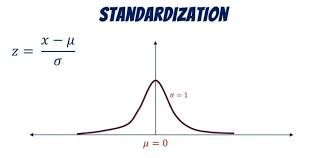


In [2]:
import csv
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt

In [3]:
#data loading and cleaning
#reading dataset
with open("/content/ObservationData_lavlqce.csv", newline="", encoding="utf-8-sig") as f:
  rows = list(csv.reader(f))
header = rows[0]
body = rows[1:]

def to_float(v):
  v = v.strip()
  return np.nan if v in ("", "NaN", "nan", "NA", "N/A", "..") else float(v)

#checking if every row has the same number of fields as the header declared above
assert all(len(r) == len(header) for r in body), "Lenth of some rows is different"

#access the first two columns and convert the rest to float
countries_list = []
years_list = []
rest = []

for r in body:
  countries_list.append(r[0])
  years_list.append(int(r[1]))
  rest.append([to_float(v) for v in r[2:]])

countries = np.array(countries_list)
years = np.array(years_list)
X = np.array(rest)

feature_names = header[2:]
print("Checking number of rows and total numeric columns\n")
print("Rows: ", X.shape[0], "| Numeric columns: ", X.shape[1],"\n")


#display some top part of data for show
def show_table(data, col_names, countries, years, n_rows=80):
    html = ['<div style="overflow-x:auto; max-height:500px; overflow-y:auto;">']
    html.append('<table style="border-collapse:collapse; font-size:12px; white-space:nowrap;">')

    # Header
    html.append('<tr style="background:#eee;">')
    html.append('<th style="border:1px solid #ccc; padding:4px;">Country</th>')
    html.append('<th style="border:1px solid #ccc; padding:4px;">Year</th>')
    for name in col_names:
        html.append(f'<th style="border:1px solid #ccc; padding:4px;">{name}</th>')
    html.append('</tr>')

    # Rows
    for i in range(min(n_rows, len(data))):
        html.append('<tr>')
        html.append(f'<td style="border:1px solid #ccc; padding:4px;">{countries[i]}</td>')
        html.append(f'<td style="border:1px solid #ccc; padding:4px;">{years[i]}</td>')
        for val in data[i]:
            val_str = "NaN" if np.isnan(val) else f"{val:.2f}"
            html.append(f'<td style="border:1px solid #ccc; padding:4px;">{val_str}</td>')
        html.append('</tr>')

    html.append('</table></div>')
    display(HTML("".join(html)))
show_table(X, feature_names, countries, years, n_rows=80)





Checking number of rows and total numeric columns

Rows:  2322 | Numeric columns:  29 



Country,Year,Real per Capita GDP Growth Rate (annual %),Real GDP growth (annual %),"Gross domestic product, (constant prices US$)","Gross domestic product, current prices (current US$)",Final consumption expenditure (current US$),General government final consumption expenditure (current US$),Household final consumption expenditure (current US$),Gross capital formation (current US$),"Gross capital formation, Private sector (current US$)","Gross capital formation, Public sector (current US$)",Exports of goods and services (current US$),Imports of goods and services (current US$),Final consumption expenditure (% of GDP),General government final consumption expenditure (% of GDP),Household final consumption expenditure (% of GDP),Gross capital formation (% of GDP),"Gross capital formation, Private sector (% GDP)","Gross capital formation, Public sector (% GDP)",Exports of goods and services (% of GDP),Imports of goods and services (% of GDP),"Central government, Fiscal Balance (Current US $)","Central government, total revenue and grants (Current US $)","Central government, total expenditure and net lending (Current US $)","Central government, Fiscal Balance (% of GDP)","Central government, total revenue and grants (% of GDP)","Central government, total expenditure and net lending (% of GDP)","Current account balance (Net, BoP, cur. US$)",Current account balance (As % of GDP),"Inflation, consumer prices (annual %)"
Malawi,1980,NaN,NaN,3038.14,2236.36,1104.30,238.76,865.54,306.24,90.26,215.98,307.48,480.36,49.38,10.68,38.70,13.69,4.04,9.66,13.75,21.48,-142.96,298.61,441.57,-6.39,13.35,19.75,-207.07,-9.26,NaN
Malawi,1981,-13.06,-10.81,2709.74,2236.40,1091.26,221.16,870.10,218.14,91.70,126.44,317.66,389.37,48.80,9.89,38.91,9.75,4.10,5.65,14.20,17.41,-133.47,276.61,410.09,-5.97,12.37,18.34,-86.71,-3.88,12.01
Malawi,1982,-0.93,1.44,2748.84,2113.68,1002.45,206.82,795.63,252.58,153.01,99.57,265.46,340.40,47.43,9.78,37.64,11.95,7.24,4.71,12.56,16.10,-119.21,254.71,373.92,-5.64,12.05,17.69,-91.15,-4.31,9.52
Malawi,1983,1.56,4.21,2864.70,2203.66,1037.06,200.81,836.26,278.87,176.89,101.98,253.84,346.54,47.06,9.11,37.95,12.65,8.03,4.63,11.52,15.73,-96.80,250.68,347.48,-4.39,11.38,15.77,-103.94,-4.72,13.77
Malawi,1984,0.54,3.92,2976.95,2157.88,1028.95,189.62,839.34,155.58,37.64,117.94,342.72,319.23,47.68,8.79,38.90,7.21,1.74,5.47,15.88,14.79,-78.94,239.30,318.24,-3.66,11.09,14.75,3.88,0.18,19.74
Malawi,1985,0.33,4.71,3117.07,2027.76,985.57,200.10,785.47,210.34,116.69,93.65,273.69,338.26,48.60,9.87,38.74,10.37,5.75,4.62,13.50,16.68,-70.51,242.60,313.12,-3.48,11.96,15.44,-72.22,-3.56,10.64
Malawi,1986,-3.27,2.03,3180.43,2124.24,1061.38,233.09,828.29,144.76,24.82,119.93,271.19,296.50,49.97,10.97,38.99,6.81,1.17,5.65,12.77,13.96,-93.34,273.05,366.39,-4.39,12.85,17.25,-41.85,-1.97,14.18
Malawi,1987,-6.76,-0.99,3148.93,2218.46,1006.64,226.01,780.63,182.05,81.18,100.87,301.12,329.01,45.38,10.19,35.19,8.21,3.66,4.55,13.57,14.83,-98.68,268.92,367.60,-4.45,12.12,16.57,-30.21,-1.36,25.05
Malawi,1988,-2.64,3.29,3252.48,2472.88,1211.61,216.80,994.81,250.07,141.22,108.85,321.83,449.07,49.00,8.77,40.23,10.11,5.71,4.40,13.01,18.16,-63.43,289.87,353.30,-2.57,11.72,14.29,-18.08,-0.73,33.85
Malawi,1989,-0.97,4.06,3384.64,2970.41,1449.96,259.76,1190.21,322.01,205.80,116.22,298.64,548.90,48.81,8.74,40.07,10.84,6.93,3.91,10.05,18.48,-23.97,378.60,402.57,-0.81,12.75,13.55,-138.06,-4.65,12.45


In [4]:
missing = np.isnan(X).sum(axis=0)
print("List of missing values in each column\n")
for name, m in zip(feature_names, missing):
    print(f"{m:4d}  ({m / len(X) * 100:4.1f}%)  {name}")
print("Total missing:", missing.sum())

List of missing values in each column

  84  ( 3.6%)  Real per Capita GDP Growth Rate (annual %)
  84  ( 3.6%)  Real GDP growth (annual %)
  30  ( 1.3%)  Gross domestic product, (constant prices US$)
  11  ( 0.5%)  Gross domestic product, current prices (current US$)
  83  ( 3.6%)  Final consumption expenditure  (current US$)
  83  ( 3.6%)  General government final consumption expenditure (current US$)
  83  ( 3.6%)  Household final consumption expenditure (current US$)
  83  ( 3.6%)  Gross capital formation (current US$)
 163  ( 7.0%)  Gross capital formation, Private sector  (current US$)
 163  ( 7.0%)  Gross capital formation, Public sector  (current US$)
  83  ( 3.6%)  Exports of goods and services (current US$)
  83  ( 3.6%)  Imports of goods and services (current US$)
  83  ( 3.6%)  Final consumption expenditure  (% of GDP)
  83  ( 3.6%)  General government final consumption expenditure (% of GDP)
  83  ( 3.6%)  Household final consumption expenditure  (% of GDP)
  83  ( 3.6%)  G

In [5]:
# calculating missing values in percent per year
print("Percent of missing values per year\n")
for y in np.unique(years):
    pct = np.isnan(X[years == y]).mean() * 100
    print(y, f"{pct:.1f}% missing")

Percent of missing values per year

1980 20.1% missing
1981 9.8% missing
1982 9.8% missing
1983 9.6% missing
1984 9.6% missing
1985 9.6% missing
1986 9.6% missing
1987 9.5% missing
1988 9.5% missing
1989 9.5% missing
1990 7.5% missing
1991 7.5% missing
1992 6.1% missing
1993 6.0% missing
1994 5.9% missing
1995 5.9% missing
1996 5.9% missing
1997 5.9% missing
1998 5.9% missing
1999 5.9% missing
2000 4.1% missing
2001 4.0% missing
2002 2.8% missing
2003 3.2% missing
2004 3.1% missing
2005 3.1% missing
2006 2.9% missing
2007 2.6% missing
2008 2.4% missing
2009 3.1% missing
2010 3.1% missing
2011 0.0% missing
2012 0.0% missing
2013 0.0% missing
2014 0.0% missing
2015 0.0% missing
2016 0.0% missing
2017 0.0% missing
2018 0.0% missing
2019 0.0% missing
2020 0.0% missing
2021 0.0% missing
2022 0.0% missing


In [6]:
# region map(african regions) is used to encode non-numeric column(countries)
region_map = {
    "Algeria": "North Africa", "Egypt": "North Africa", "Libya": "North Africa",
    "Morocco": "North Africa", "Tunisia": "North Africa",

    "Benin": "West Africa", "Burkina Faso": "West Africa", "Cabo Verde": "West Africa",
    "Cote d'Ivoire": "West Africa", "Gambia": "West Africa", "Ghana": "West Africa",
    "Guinea": "West Africa", "Guinea-Bissau": "West Africa", "Liberia": "West Africa",
    "Mali": "West Africa", "Mauritania": "West Africa", "Niger": "West Africa",
    "Nigeria": "West Africa", "Senegal": "West Africa", "Sierra Leone": "West Africa",
    "Togo": "West Africa",

    "Burundi": "East Africa", "Comoros": "East Africa", "Djibouti": "East Africa",
    "Eritrea": "East Africa", "Ethiopia": "East Africa", "Kenya": "East Africa",
    "Madagascar": "East Africa", "Malawi": "East Africa", "Mauritius": "East Africa",
    "Mozambique": "East Africa", "Rwanda": "East Africa",
    "Sao Tome and Principe": "East Africa", "Seychelles": "East Africa",
    "Somalia": "East Africa", "South Sudan": "East Africa", "Sudan": "East Africa",
    "Tanzania": "East Africa", "Uganda": "East Africa", "Zambia": "East Africa",
    "Zimbabwe": "East Africa",

    "Cameroon": "Central Africa", "Central African Republic": "Central Africa",
    "Chad": "Central Africa", "Congo, Dem. Rep.": "Central Africa",
    "Congo, Rep.": "Central Africa", "Equatorial Guinea": "Central Africa",
    "Gabon": "Central Africa",

    "Botswana": "Southern Africa", "eSwatini": "Southern Africa",
    "Angola": "Southern Africa",
    "Lesotho": "Southern Africa", "Namibia": "Southern Africa",
    "South Africa": "Southern Africa",
}

regions_full = np.array([region_map[c] for c in countries])
unique_regions = np.unique(regions_full)
print("Regions of Africa\n")
print(unique_regions,"\n")

# data encode: one column per region, 1 if the row belongs to that region, else 0
region_encoded = np.array([[1.0 if r == reg else 0.0 for reg in unique_regions]
                            for r in regions_full])
print("Data shape after encoding with regions:\n", region_encoded.shape)


Regions of Africa

['Central Africa' 'East Africa' 'North Africa' 'Southern Africa'
 'West Africa'] 

Data shape after encoding with regions:
 (2322, 5)


In [7]:
col_median = np.nanmedian(X, axis=0)

# Checking whether no column should be 100% missing (median would be nan itself)
assert not np.isnan(col_median).any(), "A column is fully empty, cannot use its median"

X_filled = X.copy()
nan_rows, nan_cols = np.where(np.isnan(X_filled))
X_filled[nan_rows, nan_cols] = col_median[nan_cols]

print("Missing values before:", np.isnan(X).sum())
print("Missing values after: ", np.isnan(X_filled).sum())

Missing values before: 3193
Missing values after:  0


In [8]:
# Now after filling missing values and adding encoded columns(regions we use to categorize)
#Final feature matrix: 29 economic indicators + 5 region columns = 34 columns
X_final = np.hstack([X_filled, region_encoded])
final_feature_names = feature_names + list(unique_regions)

print("Final shape:", X_final.shape, "\n")

show_table(X_final, final_feature_names, countries, years, n_rows=80)


Final shape: (2322, 34) 



Country,Year,Real per Capita GDP Growth Rate (annual %),Real GDP growth (annual %),"Gross domestic product, (constant prices US$)","Gross domestic product, current prices (current US$)",Final consumption expenditure (current US$),General government final consumption expenditure (current US$),Household final consumption expenditure (current US$),Gross capital formation (current US$),"Gross capital formation, Private sector (current US$)","Gross capital formation, Public sector (current US$)",Exports of goods and services (current US$),Imports of goods and services (current US$),Final consumption expenditure (% of GDP),General government final consumption expenditure (% of GDP),Household final consumption expenditure (% of GDP),Gross capital formation (% of GDP),"Gross capital formation, Private sector (% GDP)","Gross capital formation, Public sector (% GDP)",Exports of goods and services (% of GDP),Imports of goods and services (% of GDP),"Central government, Fiscal Balance (Current US $)","Central government, total revenue and grants (Current US $)","Central government, total expenditure and net lending (Current US $)","Central government, Fiscal Balance (% of GDP)","Central government, total revenue and grants (% of GDP)","Central government, total expenditure and net lending (% of GDP)","Current account balance (Net, BoP, cur. US$)",Current account balance (As % of GDP),"Inflation, consumer prices (annual %)",Central Africa,East Africa,North Africa,Southern Africa,West Africa
Malawi,1980,1.32,3.80,3038.14,2236.36,1104.30,238.76,865.54,306.24,90.26,215.98,307.48,480.36,49.38,10.68,38.70,13.69,4.04,9.66,13.75,21.48,-142.96,298.61,441.57,-6.39,13.35,19.75,-207.07,-9.26,6.20,0.00,1.00,0.00,0.00,0.00
Malawi,1981,-13.06,-10.81,2709.74,2236.40,1091.26,221.16,870.10,218.14,91.70,126.44,317.66,389.37,48.80,9.89,38.91,9.75,4.10,5.65,14.20,17.41,-133.47,276.61,410.09,-5.97,12.37,18.34,-86.71,-3.88,12.01,0.00,1.00,0.00,0.00,0.00
Malawi,1982,-0.93,1.44,2748.84,2113.68,1002.45,206.82,795.63,252.58,153.01,99.57,265.46,340.40,47.43,9.78,37.64,11.95,7.24,4.71,12.56,16.10,-119.21,254.71,373.92,-5.64,12.05,17.69,-91.15,-4.31,9.52,0.00,1.00,0.00,0.00,0.00
Malawi,1983,1.56,4.21,2864.70,2203.66,1037.06,200.81,836.26,278.87,176.89,101.98,253.84,346.54,47.06,9.11,37.95,12.65,8.03,4.63,11.52,15.73,-96.80,250.68,347.48,-4.39,11.38,15.77,-103.94,-4.72,13.77,0.00,1.00,0.00,0.00,0.00
Malawi,1984,0.54,3.92,2976.95,2157.88,1028.95,189.62,839.34,155.58,37.64,117.94,342.72,319.23,47.68,8.79,38.90,7.21,1.74,5.47,15.88,14.79,-78.94,239.30,318.24,-3.66,11.09,14.75,3.88,0.18,19.74,0.00,1.00,0.00,0.00,0.00
Malawi,1985,0.33,4.71,3117.07,2027.76,985.57,200.10,785.47,210.34,116.69,93.65,273.69,338.26,48.60,9.87,38.74,10.37,5.75,4.62,13.50,16.68,-70.51,242.60,313.12,-3.48,11.96,15.44,-72.22,-3.56,10.64,0.00,1.00,0.00,0.00,0.00
Malawi,1986,-3.27,2.03,3180.43,2124.24,1061.38,233.09,828.29,144.76,24.82,119.93,271.19,296.50,49.97,10.97,38.99,6.81,1.17,5.65,12.77,13.96,-93.34,273.05,366.39,-4.39,12.85,17.25,-41.85,-1.97,14.18,0.00,1.00,0.00,0.00,0.00
Malawi,1987,-6.76,-0.99,3148.93,2218.46,1006.64,226.01,780.63,182.05,81.18,100.87,301.12,329.01,45.38,10.19,35.19,8.21,3.66,4.55,13.57,14.83,-98.68,268.92,367.60,-4.45,12.12,16.57,-30.21,-1.36,25.05,0.00,1.00,0.00,0.00,0.00
Malawi,1988,-2.64,3.29,3252.48,2472.88,1211.61,216.80,994.81,250.07,141.22,108.85,321.83,449.07,49.00,8.77,40.23,10.11,5.71,4.40,13.01,18.16,-63.43,289.87,353.30,-2.57,11.72,14.29,-18.08,-0.73,33.85,0.00,1.00,0.00,0.00,0.00
Malawi,1989,-0.97,4.06,3384.64,2970.41,1449.96,259.76,1190.21,322.01,205.80,116.22,298.64,548.90,48.81,8.74,40.07,10.84,6.93,3.91,10.05,18.48,-23.97,378.60,402.57,-0.81,12.75,13.55,-138.06,-4.65,12.45,0.00,1.00,0.00,0.00,0.00


In [9]:
# Step 1:Standardize the data
mean = X_final.mean(axis=0)
std = X_final.std(axis=0)


# cheching if std = 0 would cause a divide-by-zero
assert not np.any(std == 0), "A column has zero variance, standardization would fail"


standardized_data = (X_final - mean) / std
standardized_data[:5]




array([[ 3.37459151e-02,  2.76706812e-02, -3.79703732e-01,
        -3.60433700e-01, -3.57926794e-01, -3.55935139e-01,
        -3.45355007e-01, -3.81120472e-01, -3.75162587e-01,
        -3.06548498e-01, -4.00018527e-01, -4.21219024e-01,
        -1.37055228e+00, -6.03861937e-01, -1.23544970e+00,
        -6.73575127e-01, -8.51406408e-01,  4.24944869e-02,
        -7.34464068e-01, -7.03085238e-01,  1.94773832e-01,
        -3.68519434e-01, -3.58390588e-01, -3.26377751e-01,
        -7.23204298e-01, -4.22612395e-01,  5.93169674e-02,
        -3.81374477e-01, -2.03287974e-01, -3.85922492e-01,
         1.30384048e+00, -3.19438282e-01, -3.53553391e-01,
        -6.48885685e-01],
       [-1.78409878e+00, -1.75756301e+00, -3.84914815e-01,
        -3.60432992e-01, -3.58217334e-01, -3.58122190e-01,
        -3.45235668e-01, -3.88151797e-01, -3.74974641e-01,
        -3.21565032e-01, -3.99305621e-01, -4.27663156e-01,
        -1.39570827e+00, -7.12841180e-01, -1.22591482e+00,
        -1.04313492e+00, -8.44

In [10]:
print("Confirming the mean value of each column after standardizing:\n")
print(standardized_data.mean(axis=0).round(3))

print("\nStandard deviation of each column after standardization:\n")
print(standardized_data.std(axis=0).round(3))

Confirming the mean value of each column after standardizing:

[-0. -0.  0. -0.  0. -0.  0.  0. -0. -0. -0. -0. -0. -0.  0. -0. -0. -0.
  0.  0. -0.  0.  0. -0.  0. -0.  0. -0. -0. -0.  0. -0.  0. -0.]

Standard deviation of each column after standardization:

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [11]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]

cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)

cov_matrix


array([[ 1.00043085e+00,  9.91549537e-01,  5.97115901e-03, ...,
         2.38099450e-02,  1.65795904e-02, -1.07029325e-02],
       [ 9.91549537e-01,  1.00043085e+00, -6.97780827e-03, ...,
        -2.41713973e-03,  4.48344359e-04,  7.16708417e-03],
       [ 5.97115901e-03, -6.97780827e-03,  1.00043085e+00, ...,
         2.95069228e-01,  2.03154186e-01, -4.09588734e-02],
       ...,
       [ 2.38099450e-02, -2.41713973e-03,  2.95069228e-01, ...,
         1.00043085e+00, -1.12987147e-01, -2.07368234e-01],
       [ 1.65795904e-02,  4.48344359e-04,  2.03154186e-01, ...,
        -1.12987147e-01,  1.00043085e+00, -2.29514577e-01],
       [-1.07029325e-02,  7.16708417e-03, -4.09588734e-02, ...,
        -2.07368234e-01, -2.29514577e-01,  1.00043085e+00]])

In [23]:
print("checking about the covariance matrix\n")
print("Shape of matrix:", cov_matrix.shape,"\n")
print("Is Symmetric:", np.allclose(cov_matrix, cov_matrix.T),"\n")
print("Diagonal sample :", np.diag(cov_matrix)[:5])

checking about the covariance matrix

Shape of matrix: (34, 34) 

Is Symmetric: True 

Diagonal sample : [1.00043085 1.00043085 1.00043085 1.00043085 1.00043085]


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute a covariance matrix to see how different features in a dataset are related to each other. It helps us know whether two features increase or decrease together. In PCA the covariance matrix is also used to find the directions with the most variation in the data which helps reduce the number of features while keeping important  information.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [13]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

eigenvalues, eigenvectors

(array([1.55431223e-15, 4.55056615e-10, 3.08361650e-06, 6.89826112e-04,
        1.55668812e-03, 6.80963267e-03, 8.51629259e-03, 1.15854254e-02,
        1.78909059e-02, 3.19526142e-02, 4.79085506e-02, 5.64816862e-02,
        6.96634274e-02, 1.05416043e-01, 1.50003984e-01, 2.04844514e-01,
        3.34671736e-01, 3.95582520e-01, 4.39133536e-01, 4.93890017e-01,
        5.21171266e-01, 6.89441905e-01, 7.28287574e-01, 9.46581945e-01,
        9.88754514e-01, 1.15815442e+00, 1.28243745e+00, 1.41413413e+00,
        1.56755277e+00, 1.74665582e+00, 2.16735015e+00, 2.92887357e+00,
        4.18371791e+00, 1.13149350e+01]),
 array([[-1.81879281e-14, -1.77282979e-06, -7.49125684e-04, ...,
         -2.37564095e-01,  8.21773094e-02, -5.04590118e-03],
        [-9.68071286e-15,  1.01542767e-06,  8.22414870e-04, ...,
         -2.41831907e-01,  6.71429846e-02, -1.75447746e-04],
        [ 9.09890347e-14,  1.63937436e-06,  9.81048869e-05, ...,
         -1.12542804e-02, -5.88756933e-02, -2.78922862e-01],
    

In [14]:
print("Number of eigenvalues:", len(eigenvalues))
print("Eigenvector matrix shape:", eigenvectors.shape)
print("First few eigenvalues:", eigenvalues[:5])
print("Largest eigenvalue:", eigenvalues[-1])

Number of eigenvalues: 34
Eigenvector matrix shape: (34, 34)
First few eigenvalues: [1.55431223e-15 4.55056615e-10 3.08361650e-06 6.89826112e-04
 1.55668812e-03]
Largest eigenvalue: 11.314934950171219


In [15]:
print("Sum of eigenvalues:      ", eigenvalues.sum())
print("Sum of covariance diagonal (trace):", np.trace(cov_matrix))

Sum of eigenvalues:       34.014648858250716
Sum of covariance diagonal (trace): 34.014648858250716


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [16]:
# Step 5: Sort Principal Components

# indices that sort eigenvalues, largest first
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

sorted_eigenvectors

array([[-5.04590118e-03,  8.21773094e-02, -2.37564095e-01, ...,
        -7.49125684e-04, -1.77282979e-06, -1.81879281e-14],
       [-1.75447746e-04,  6.71429846e-02, -2.41831907e-01, ...,
         8.22414870e-04,  1.01542767e-06, -9.68071286e-15],
       [-2.78922862e-01, -5.88756933e-02, -1.12542804e-02, ...,
         9.81048869e-05,  1.63937436e-06,  9.09890347e-14],
       ...,
       [-1.19276774e-01,  1.11634046e-01, -6.14439590e-02, ...,
         7.96790073e-05, -3.93564791e-07, -3.37569976e-01],
       [-5.97123968e-02,  1.90186604e-01, -4.83280737e-02, ...,
         3.62853428e-05,  4.08444700e-07, -3.65996569e-01],
       [ 2.69352239e-02, -1.28950170e-01,  9.45119854e-03, ...,
        -1.23528214e-05,  6.41578973e-08, -5.31780686e-01]])

In [17]:
explained_variance = sorted_eigenvalues / sorted_eigenvalues.sum() * 100
cumulative_variance = np.cumsum(explained_variance)

for i in range(len(explained_variance)):
    print(f"PC{i+1}: {explained_variance[i]:5.2f}%   cumulative: {cumulative_variance[i]:6.2f}%")

PC1: 33.26%   cumulative:  33.26%
PC2: 12.30%   cumulative:  45.56%
PC3:  8.61%   cumulative:  54.18%
PC4:  6.37%   cumulative:  60.55%
PC5:  5.14%   cumulative:  65.68%
PC6:  4.61%   cumulative:  70.29%
PC7:  4.16%   cumulative:  74.45%
PC8:  3.77%   cumulative:  78.22%
PC9:  3.40%   cumulative:  81.62%
PC10:  2.91%   cumulative:  84.53%
PC11:  2.78%   cumulative:  87.31%
PC12:  2.14%   cumulative:  89.45%
PC13:  2.03%   cumulative:  91.48%
PC14:  1.53%   cumulative:  93.01%
PC15:  1.45%   cumulative:  94.47%
PC16:  1.29%   cumulative:  95.76%
PC17:  1.16%   cumulative:  96.92%
PC18:  0.98%   cumulative:  97.90%
PC19:  0.60%   cumulative:  98.51%
PC20:  0.44%   cumulative:  98.95%
PC21:  0.31%   cumulative:  99.26%
PC22:  0.20%   cumulative:  99.46%
PC23:  0.17%   cumulative:  99.63%
PC24:  0.14%   cumulative:  99.77%
PC25:  0.09%   cumulative:  99.86%
PC26:  0.05%   cumulative:  99.91%
PC27:  0.03%   cumulative:  99.95%
PC28:  0.03%   cumulative:  99.97%
PC29:  0.02%   cumulative:  9

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [18]:
# Step 6: Project Data onto Principal Components
num_components = np.argmax(cumulative_variance >= 90) + 1

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]

reduced_data[:5]

array([[ 1.40226253, -1.60233079, -0.49222629, -0.60044095,  0.04291395,
         1.55757196,  0.2345942 , -1.21149262, -0.68811786, -0.19577015,
         0.93033474, -0.29912754,  0.03281863],
       [ 1.42796225, -2.35238823,  0.11700798, -2.62707317, -0.14139226,
         0.53711326,  0.89686787, -1.26784934, -0.0914596 , -0.58647821,
         0.89646187, -0.01266309,  0.04139815],
       [ 1.39772614, -2.07766268, -0.66886434, -1.10375687, -0.00656502,
         1.53330793,  0.39652214, -0.7176878 , -0.51100907, -0.50585136,
         0.84075506, -0.15393215,  0.04876271],
       [ 1.40255007, -2.13838049, -0.87263601, -0.68851648,  0.05598858,
         1.71050977,  0.38403716, -0.64630663, -0.60088323, -0.55755809,
         0.68034772, -0.09807275, -0.04337076],
       [ 1.45595643, -2.53021096, -1.03768232, -0.84126773, -0.57801087,
         1.43870912,  0.41996975, -0.93761257, -0.74935016, -0.07107638,
         0.58705029,  0.16628209,  0.13023909]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [19]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')
reduced_data[:5]

Reduced Data Shape: (2322, 13)


array([[ 1.40226253, -1.60233079, -0.49222629, -0.60044095,  0.04291395,
         1.55757196,  0.2345942 , -1.21149262, -0.68811786, -0.19577015,
         0.93033474, -0.29912754,  0.03281863],
       [ 1.42796225, -2.35238823,  0.11700798, -2.62707317, -0.14139226,
         0.53711326,  0.89686787, -1.26784934, -0.0914596 , -0.58647821,
         0.89646187, -0.01266309,  0.04139815],
       [ 1.39772614, -2.07766268, -0.66886434, -1.10375687, -0.00656502,
         1.53330793,  0.39652214, -0.7176878 , -0.51100907, -0.50585136,
         0.84075506, -0.15393215,  0.04876271],
       [ 1.40255007, -2.13838049, -0.87263601, -0.68851648,  0.05598858,
         1.71050977,  0.38403716, -0.64630663, -0.60088323, -0.55755809,
         0.68034772, -0.09807275, -0.04337076],
       [ 1.45595643, -2.53021096, -1.03768232, -0.84126773, -0.57801087,
         1.43870912,  0.41996975, -0.93761257, -0.74935016, -0.07107638,
         0.58705029,  0.16628209,  0.13023909]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

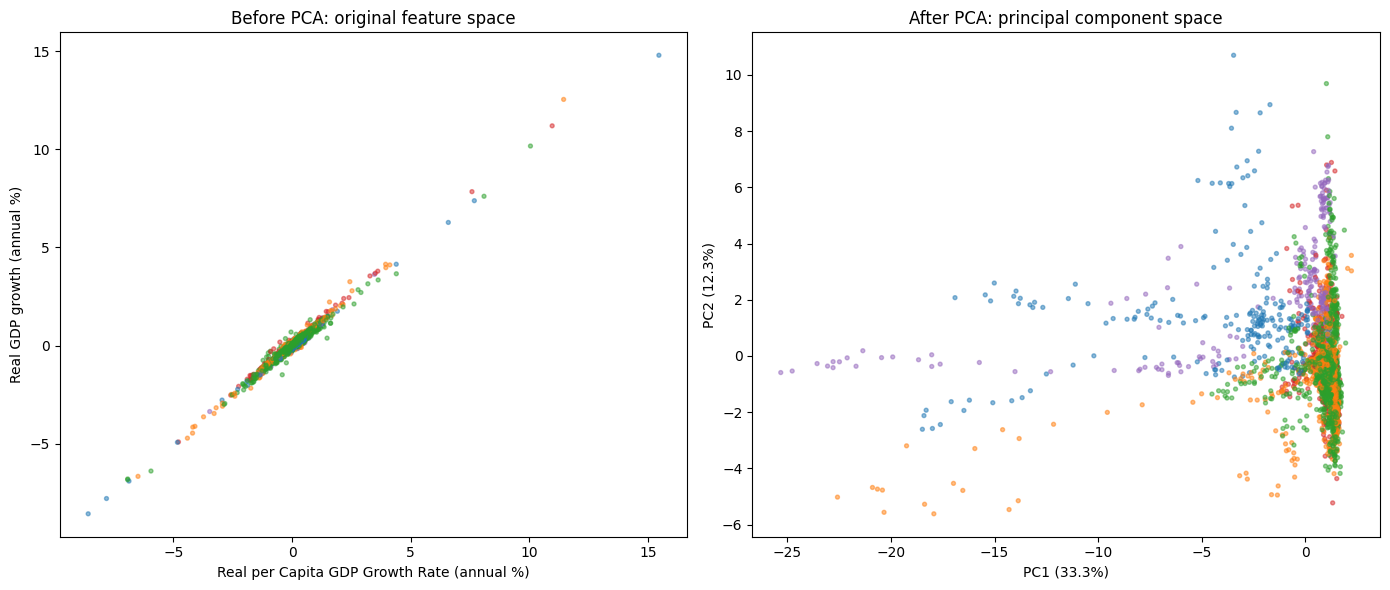

In [20]:
# Step 8: Visualize Before and After PCA
region_colors = {"North Africa": "tab:blue", "West Africa": "tab:orange",
                  "East Africa": "tab:green", "Central Africa": "tab:red",
                  "Southern Africa": "tab:purple"}
point_colors = [region_colors[r] for r in regions_full]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot original data (first two features for simplicity)
axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1],
                 c=point_colors, s=8, alpha=0.5)
axes[0].set_xlabel(final_feature_names[0])
axes[0].set_ylabel(final_feature_names[1])
axes[0].set_title("Before PCA: original feature space")
# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1],
                 c=point_colors, s=8, alpha=0.5)
axes[1].set_xlabel(f"PC1 ({explained_variance[0]:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained_variance[1]:.1f}%)")
axes[1].set_title("After PCA: principal component space")

plt.tight_layout()
plt.show()



Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. Interpret the Visual you just created of the before and after PCA

There are 34 features we used but the before graph is only showing the first two(the first two features(3rd and 4th columns). It looks straight line because their measurement is almost identical like having comparable values(slightly different amounts). The after graph makes use of all 34 features so shows the real economic structure. PC1(33.3% variance) represents the overall economic size and PC2(12.3%) represents economic structure interms of GDP. The clustered(respective color) shows countries in the same region have similar economy.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

Our threshold was 90%, so we chose 13 components because they make up 91% variance just slightly bigger than threshold. So we reduced from 34 columns to 13. This has tradeoffs since we dropped those which make up remaining nearly 9% variance. If we kept all, it would keep more data but we wanted to use dimensionality reduction.





3.Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


Since we reduced features to 13, means we lost the original indicators from other features, for instance, PC1 represents GDP, imports and government spending as economic size signal so we can't know which specific factor is changed for a country-year.We also lose year-to-year detail in single country as PCA doesn't prioritizes small local changes(it prioritizes patterns in whole dataset).